## Time series analysis of lateral velocity:
This notebook analyses the variation in lateral velocity, $`u_y`$, over time to detect von Kármán vortex shedding and how surpression of this may contribute to reduced drag coefficient. Analysis was conducted with free stream velocity of $`0.1`$ m s $`^{-1}`$.

`time_series.csv` and `FFT.csv` files for each taxon were created manually in paraview (see `time_series_analysis.pvsm` in `[taxon]/velocity/v0.1/postProcessing/`).

In [1]:
#import libraries:
import numpy as np
import paraview
import glob
import os
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches
from matplotlib.legend_handler import HandlerLine2D, HandlerTuple
from scipy.signal import welch
import csv
import gc
import pandas as pd
import parameters as par
import functions as func

### Edrioasteroids

In [2]:
# Setting up lists of taxa and Re.
taxa = [
    par.Stromatocystites, 
    par.Kailidiscus, 
    par.Helicocystis_straight, 
    par.Helicocystis, 
    par.Gogia_palmeri, 
    par.Gogia_spiralis
]
Re = [100, 500, 1000, 5000, 10000]

# Setting up a results dictionary:
results = {taxa[i].name: {} for i in range(len(taxa))}
for i in range(len(taxa)):
    results[taxa[i].name] = {Re[j]: [] for j in range(len(Re))}

for i in range(len(taxa)):
    for j in range(len(Re)):
        results[taxa[i].name][Re[j]] = {"strouhal": [], "psd": []}

print(results)

{'stromatocystites': {100: {'strouhal': [], 'psd': []}, 500: {'strouhal': [], 'psd': []}, 1000: {'strouhal': [], 'psd': []}, 5000: {'strouhal': [], 'psd': []}, 10000: {'strouhal': [], 'psd': []}}, 'kailidiscus': {100: {'strouhal': [], 'psd': []}, 500: {'strouhal': [], 'psd': []}, 1000: {'strouhal': [], 'psd': []}, 5000: {'strouhal': [], 'psd': []}, 10000: {'strouhal': [], 'psd': []}}, 'helicocystis_straight': {100: {'strouhal': [], 'psd': []}, 500: {'strouhal': [], 'psd': []}, 1000: {'strouhal': [], 'psd': []}, 5000: {'strouhal': [], 'psd': []}, 10000: {'strouhal': [], 'psd': []}}, 'helicocystis': {100: {'strouhal': [], 'psd': []}, 500: {'strouhal': [], 'psd': []}, 1000: {'strouhal': [], 'psd': []}, 5000: {'strouhal': [], 'psd': []}, 10000: {'strouhal': [], 'psd': []}}, 'gogia_palmeri': {100: {'strouhal': [], 'psd': []}, 500: {'strouhal': [], 'psd': []}, 1000: {'strouhal': [], 'psd': []}, 5000: {'strouhal': [], 'psd': []}, 10000: {'strouhal': [], 'psd': []}}, 'gogia_spiralis': {100: {'

In [3]:
strouhal = np.zeros((len(taxa), len(Re)))
psd = np.zeros((len(taxa), len(Re)))

# For each taxon and Re, calculates strouhal and psd arrays and adds them to a dictionary:

for i in range(len(taxa)):
    for j in range(len(Re)):
        print(f"calculating strouhal for {taxa[i].name} at Re={Re[j]}")
        results[taxa[i].name][Re[j]]["strouhal"] = func.calc_FFT(
            taxon = taxa[i].name, 
            file = 'probe.csv', 
            L = taxa[i].L, 
            Re = Re[j], 
            flow_through_time = taxa[i].cfd["Re" + str(Re[j])]['flow_through_time'], 
            endTime = taxa[i].cfd["Re" + str(Re[j])]['time_range'][1]*taxa[i].cfd["Re" + str(Re[j])]['write_interval'], 
            writeInterval = taxa[i].cfd["Re" + str(Re[j])]['write_interval'], 
            nu = par.Env1.nu
        )["strouhal"]
        print(f"calculating psd for {taxa[i].name} at Re={Re[j]} \n")
        results[taxa[i].name][Re[j]]["psd"] = func.calc_FFT(
            taxon = taxa[i].name, 
            file = 'probe.csv', 
            L = taxa[i].L, 
            Re = Re[j], 
            flow_through_time = taxa[i].cfd["Re" + str(Re[j])]['flow_through_time'], 
            endTime = taxa[i].cfd["Re" + str(Re[j])]['time_range'][1]*taxa[i].cfd["Re" + str(Re[j])]['write_interval'], 
            writeInterval = taxa[i].cfd["Re" + str(Re[j])]['write_interval'], 
            nu = par.Env1.nu
        )["psd"]


#data = pd.dframe({
#    'taxon': np.repeat([taxon.name for taxon in taxa], len(Re)),
#    'Re': np.tile(Re, len(taxa)),
#    'strouhal': strouhal.flatten(),
#    'psd': psd.flatten()
#})

print(results)
#kaili_5000 = func.calc_FFT(taxon = par.Kailidiscus.name, 
#                            file = 'probe.csv', 
#                            L = par.Kailidiscus.L, 
#                            Re = 5000, 
#                            flow_through_time = 2.58, 
#                            endTime = 13, 
#                            writeInterval = 0.05, 
#                            nu = par.Env1.nu)
#fig = plt.figure()
#plt.plot(kaili_5000['strouhal'], kaili_5000['psd'], label=par.Kailidiscus.label)
#plt.show()

calculating strouhal for stromatocystites at Re=100
     Peak occurs at St =  0.06760817307692307
calculating psd for stromatocystites at Re=100 

     Peak occurs at St =  0.06760817307692307
calculating strouhal for stromatocystites at Re=500
     Peak occurs at St =  0.054086538461538464
calculating psd for stromatocystites at Re=500 

     Peak occurs at St =  0.054086538461538464
calculating strouhal for stromatocystites at Re=1000
     Peak occurs at St =  0.20282451923076925
calculating psd for stromatocystites at Re=1000 

     Peak occurs at St =  0.20282451923076925
calculating strouhal for stromatocystites at Re=5000
     Peak occurs at St =  0.21634615384615383
calculating psd for stromatocystites at Re=5000 

     Peak occurs at St =  0.21634615384615383
calculating strouhal for stromatocystites at Re=10000
     Peak occurs at St =  0.20282451923076925
calculating psd for stromatocystites at Re=10000 

     Peak occurs at St =  0.20282451923076925
calculating strouhal for 

/mnt/apps/users/jmcdermo/conda/lib/python3.12/site-packages/scipy/signal/_spectral_py.py:790: UserWarning: nperseg = 64 is greater than input length  = 45, using nperseg = 45
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,


     Peak occurs at St =  0.07692307692307694
calculating psd for helicocystis_straight at Re=500 

     Peak occurs at St =  0.07692307692307694
calculating strouhal for helicocystis_straight at Re=1000
     Peak occurs at St =  0.13521634615384617
calculating psd for helicocystis_straight at Re=1000 

     Peak occurs at St =  0.13521634615384617
calculating strouhal for helicocystis_straight at Re=5000
     Peak occurs at St =  0.1622596153846154
calculating psd for helicocystis_straight at Re=5000 

     Peak occurs at St =  0.1622596153846154
calculating strouhal for helicocystis_straight at Re=10000
     Peak occurs at St =  0.18930288461538464
calculating psd for helicocystis_straight at Re=10000 

     Peak occurs at St =  0.18930288461538464
calculating strouhal for helicocystis at Re=100
     Peak occurs at St =  0.027043269230769235
calculating psd for helicocystis at Re=100 

     Peak occurs at St =  0.027043269230769235
calculating strouhal for helicocystis at Re=500
    

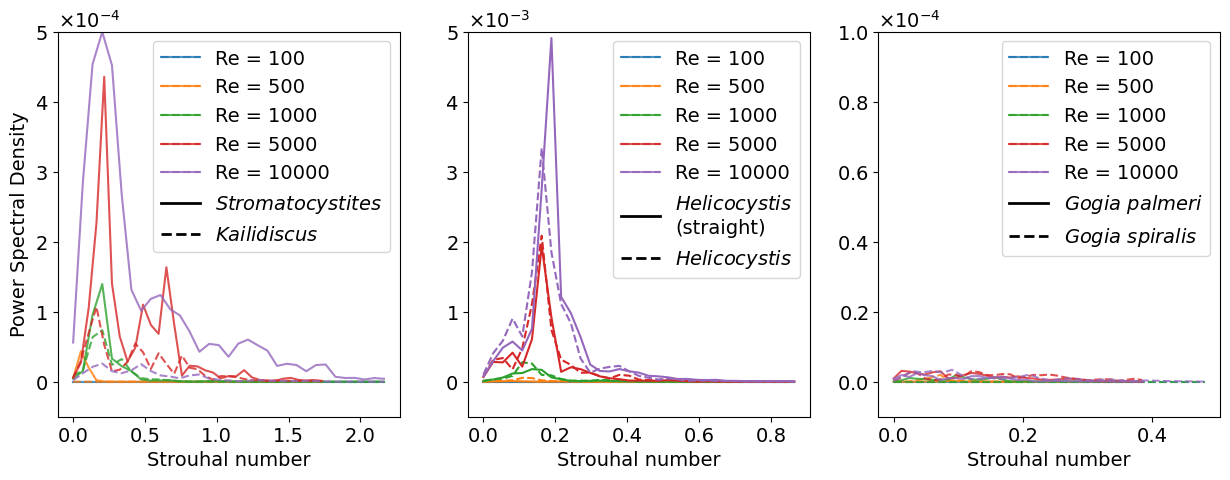

In [4]:
colours_st = ['#03045e', '#023e8a', '#0077b6', '#00b4d8', '#ade8f4']
colours_sp = ['#FD5602', '#FE6E00', '#FF8303', '#FFAF42', '#FEDEBE']
colours = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']
plt.rcParams.update({'font.size': 14})

fig, axs = plt.subplots(
    1,3, 
    figsize = (15,5)#, 
    #sharey=True
    )

lines_0 = []
for i in Re:
    line1, = axs[0].plot(
        results["stromatocystites"][i]['strouhal'], results["stromatocystites"][i]['psd'], 
        alpha=0.8, 
        color = colours[Re.index(i)]
        )
    line2, = axs[0].plot(
        results["kailidiscus"][i]['strouhal'], results["kailidiscus"][i]['psd'], 
        alpha=0.8, 
        color = colours[Re.index(i)],
        linestyle = '--'
        )
    lines_0.append((line1, line2))

    axs[1].plot(
        results["helicocystis_straight"][i]['strouhal'], results["helicocystis_straight"][i]['psd'], 
        label=str(i), 
        alpha=1, 
        color = colours[Re.index(i)]
        )
    axs[1].plot(
        results["helicocystis"][i]['strouhal'], results["helicocystis"][i]['psd'], 
        label=str(i), 
        alpha=1, 
        color = colours[Re.index(i)],
        linestyle = '--'
        )

    axs[2].plot(
        results["gogia_palmeri"][i]['strouhal'], results["gogia_palmeri"][i]['psd'], 
        label=str(i), 
        alpha=0.8, 
        color = colours[Re.index(i)]
        )
    axs[2].plot(
        results["gogia_spiralis"][i]['strouhal'], results["gogia_spiralis"][i]['psd'], 
        label=str(i), 
        alpha=0.8, 
        color = colours[Re.index(i)],
        linestyle = '--'
        )

subplot_type_handles = [
    [Line2D([0],[0], color='black', linestyle='-', linewidth=2, label=r"$\it{Stromatocystites}$"),
     Line2D([0],[0], color='black', linestyle='--', linewidth=2, label=r"$\it{Kailidiscus}$")],
    [Line2D([0],[0], color='black', linestyle='-', linewidth=2, label=r"$\it{Helicocystis}$"
                                                                        "\n"
                                                                        "(straight)"),
     Line2D([0],[0], color='black', linestyle='--', linewidth=2, label=r"$\it{Helicocystis}$")],
    [Line2D([0],[0], color='black', linestyle='-', linewidth=2, label=r"$\it{Gogia\ palmeri}$"),
     Line2D([0],[0], color='black', linestyle='--', linewidth=2, label=r"$\it{Gogia\ spiralis}$")]
]

for idx in range(3):
    handles = lines_0 + subplot_type_handles[idx]
    labels = ["Re = " +str(r) for r in Re] + [h.get_label() for h in subplot_type_handles[idx]]
    axs[idx].legend(handles=handles, labels=labels)#, handler_map={tuple: HandlerTuple(ndivide=None)})
    #axs[idx].set_xlim(0,1)
    axs[idx].set_xlabel('Strouhal number')

axs[0].ticklabel_format(axis='y', style='sci', scilimits=(0, 0), useMathText=True)
axs[1].ticklabel_format(axis='y', style='sci', scilimits=(0, 0), useMathText=True)
axs[2].ticklabel_format(axis='y', style='sci', scilimits=(0, 0), useMathText=True)

#axs[0].ticklabel_format('sci', useMathText=True)
#axs[0].set_title(r"$\it{Stromatocystites}$ / $\it{Kailidiscus}$")
#axs[1].set_title(r"$\it{Helicocystis}$ (straight) / $\it{Helicocystis}$")
#axs[2].set_title(r"$\it{Gogia\ palmeri}$ / $\it{Gogia\ spiralis}$")
axs[0].set_ylabel('Power Spectral Density')
axs[0].set_ylim(-0.5E-4, 5E-4)
axs[1].set_ylim(-0.5E-3, 5E-3)
axs[2].set_ylim(-0.1E-4,10E-5)
axs[0].set_yticks([0, 1E-4, 2E-4, 3E-4, 4E-4, 5E-4])
axs[1].set_yticks([0, 1E-3, 2E-3, 3E-3, 4E-3, 5E-3])
axs[2].set_yticks([0, 2E-5, 4E-5, 6E-5, 8E-5, 10E-5])

#plt.savefig('figures/psd.pdf', bbox_inches='tight', dpi=400)


### Conference figure:

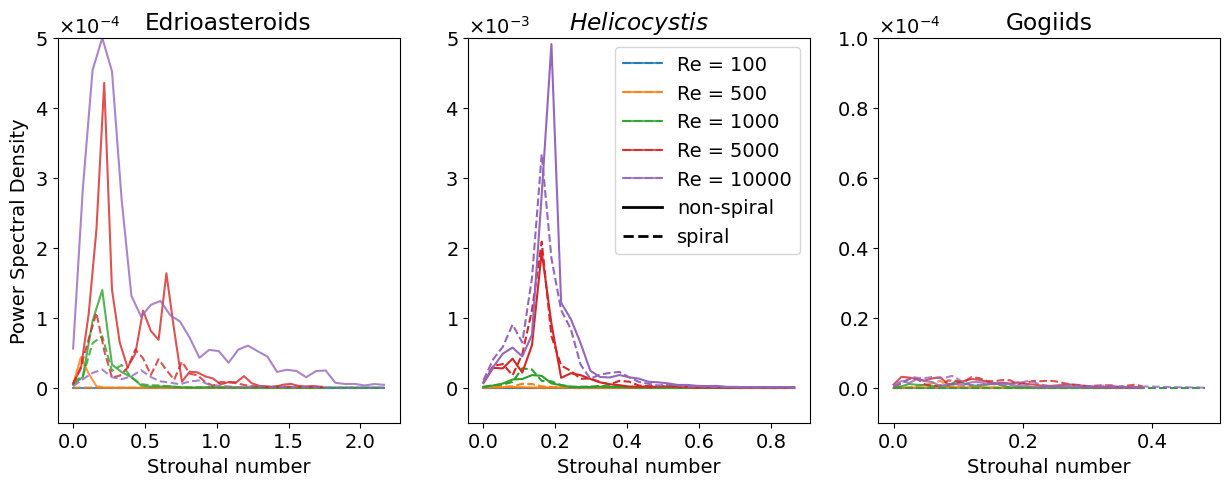

In [5]:
colours_st = ['#03045e', '#023e8a', '#0077b6', '#00b4d8', '#ade8f4']
colours_sp = ['#FD5602', '#FE6E00', '#FF8303', '#FFAF42', '#FEDEBE']
colours = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']
plt.rcParams.update({'font.size': 14})

fig, axs = plt.subplots(
    1,3, 
    figsize = (15,5)#, 
    #sharey=True
    )

lines_0 = []
for i in Re:
    line1, = axs[0].plot(
        results["stromatocystites"][i]['strouhal'], results["stromatocystites"][i]['psd'], 
        alpha=0.8, 
        color = colours[Re.index(i)]
        )
    line2, = axs[0].plot(
        results["kailidiscus"][i]['strouhal'], results["kailidiscus"][i]['psd'], 
        alpha=0.8, 
        color = colours[Re.index(i)],
        linestyle = '--'
        )
    lines_0.append((line1, line2))

    axs[1].plot(
        results["helicocystis_straight"][i]['strouhal'], results["helicocystis_straight"][i]['psd'], 
        label=str(i), 
        alpha=1, 
        color = colours[Re.index(i)]
        )
    axs[1].plot(
        results["helicocystis"][i]['strouhal'], results["helicocystis"][i]['psd'], 
        label=str(i), 
        alpha=1, 
        color = colours[Re.index(i)],
        linestyle = '--'
        )

    axs[2].plot(
        results["gogia_palmeri"][i]['strouhal'], results["gogia_palmeri"][i]['psd'], 
        label=str(i), 
        alpha=0.8, 
        color = colours[Re.index(i)]
        )
    axs[2].plot(
        results["gogia_spiralis"][i]['strouhal'], results["gogia_spiralis"][i]['psd'], 
        label=str(i), 
        alpha=0.8, 
        color = colours[Re.index(i)],
        linestyle = '--'
        )

subplot_type_handles = [
    [Line2D([0],[0], color='black', linestyle='-', linewidth=2, label=r"$\it{Stromatocystites}$"),
     Line2D([0],[0], color='black', linestyle='--', linewidth=2, label=r"$\it{Kailidiscus}$")],
    [Line2D([0],[0], color='black', linestyle='-', linewidth=2, label=r"$\it{Helicocystis}$"
                                                                        "\n"
                                                                        "(straight)"),
     Line2D([0],[0], color='black', linestyle='--', linewidth=2, label=r"$\it{Helicocystis}$")],
    [Line2D([0],[0], color='black', linestyle='-', linewidth=2, label="non-spiral"),
     Line2D([0],[0], color='black', linestyle='--', linewidth=2, label="spiral")]
]

for idx in range(3):
    handles = lines_0 + subplot_type_handles[idx]
    labels = ["Re = " +str(r) for r in Re] + [h.get_label() for h in subplot_type_handles[idx]]
    #axs[idx].legend(handles=handles, labels=labels)#, handler_map={tuple: HandlerTuple(ndivide=None)})
    #axs[idx].set_xlim(0,1)
    axs[idx].set_xlabel('Strouhal number')

axs[1].legend(handles=handles, labels=labels, loc='upper right', fontsize=14)

axs[0].ticklabel_format(axis='y', style='sci', scilimits=(0, 0), useMathText=True)
axs[1].ticklabel_format(axis='y', style='sci', scilimits=(0, 0), useMathText=True)
axs[2].ticklabel_format(axis='y', style='sci', scilimits=(0, 0), useMathText=True)

#axs[0].ticklabel_format('sci', useMathText=True)
#axs[0].set_title(r"$\it{Stromatocystites}$ / $\it{Kailidiscus}$")
#axs[1].set_title(r"$\it{Helicocystis}$ (straight) / $\it{Helicocystis}$")
#axs[2].set_title(r"$\it{Gogia\ palmeri}$ / $\it{Gogia\ spiralis}$")
axs[0].set_ylabel('Power Spectral Density')
axs[0].set_ylim(-0.5E-4, 5E-4)
axs[1].set_ylim(-0.5E-3, 5E-3)
axs[2].set_ylim(-0.1E-4,10E-5)
axs[0].set_yticks([0, 1E-4, 2E-4, 3E-4, 4E-4, 5E-4])
axs[1].set_yticks([0, 1E-3, 2E-3, 3E-3, 4E-3, 5E-3])
axs[2].set_yticks([0, 2E-5, 4E-5, 6E-5, 8E-5, 10E-5])

axs[0].set_title("Edrioasteroids")
axs[1].set_title(r"$\it{Helicocystis}$")
axs[2].set_title("Gogiids")

plt.savefig('figures/psd_conference.png', bbox_inches='tight', dpi=400)
